## DSM150 Neural Networks: 

Midterm coursework assignment

Fasion classification using the TensorFlow fashion MNIST dataset

### Step 1: Define the problem and assemble the dataset

#### Definition of the problem:

The fashion_mnist dataset contains 28 x 28 greyscale images of clothing items. The data is split into a training and test set. The training set contains 60,000 images and the test set 10,000 images.

The MNIST dataset has been overused by researchers, it is too simple and therefore convolutional networks can easily obtain 99.7% accuracy, so  Fashion MNIST is the new benchmark in computer vision tasks. https://github.com/zalandoresearch/fashion-mnist/blob/master/README.md

The problem statement: predict the correct category of clothing correctly. (from 0 to 9)

The objective: minimize the classification error on unseen test images.

Coding inspired by University of London lectures and other online examples of the Fashion MNIST dataset, such as:
https://colab.research.google.com/github/goodboychan/chans_jupyter/blob/main/_notebooks/2020-09-21-01-Image-Classification-with-Fashion-MNIST.ipynb
https://github.com/Gurinder01/fashion-mnist-cnn-classification/blob/main/Fashion%20MNSIT%20Project%20-%20CNN.ipynb
https://github.com/zalandoresearch/fashion-mnist/blob/master/README.md
https://www.tensorflow.org/tutorials/keras/classification

In [254]:
""" Libraries required for this project

    Modelling
    ---------
    tensorflow:  layers = models, layers, sequential, Conv2D, MaxPooling2D, Dense, Flatten
    keras: to_categorical
    numpy
    pandas
    matplotlib
    seaborne
    sklearn

    Optimizer = Adam

    Dataset = Fashion MNIST

    Cross validation
    ----------------
    Kfold, accuracy score, classification report
    
"""    
# Import the libraries
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import random
import seaborn as sns

from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras import regularizers

# import hidden layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, BatchNormalization

# Adam optimizer: has a better learning rate and reduced loss
from tensorflow.keras.optimizers import Adam

# Import the fashion mnist dataset
from tensorflow.keras.datasets import fashion_mnist

# Import for k-fold cross validation
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Set seeds for Python, NumPy, and TensorFlow to ensure reproducibility 
random.seed(13)
np.random.seed(13)
keras.utils.set_random_seed(13) # Sets NumPy, Python, and TF seeds

print(tf.__version__, ' ', tf.keras.__version__)

2.20.0   3.11.3


#### Load the dataset

In [4]:
# import the dataset
(x_train_images, y_train_labels), (x_test_images, y_test_labels) = fashion_mnist.load_data()

x_train_images and y_train_labels are arrays in the training dataset which a model will use to learn from.

x_test_images and y_test_labels are also arrays that will be used by a model to test it.

In [5]:
# print training images shape
x_train_images.shape

(60000, 28, 28)

There are a total of 60000 greyscale images in the training data each image is of size 28 x 28 pixels in size. images have pixel values ranging from 0 to 255.

In [6]:
# print length of training labels dataset
len(y_train_labels)

60000

There are also 60000 training labels to match the training data. The labels correspond to the class of clothing the image represents:

0 = T-shirt/top; 1 = Trouser; 2 = Pullover; 3 =	Dress; 4 = Coat; 5 = Sandal; 6 = Shirt; 7 =	Sneaker; 8 = Bag; 9 = Ankle boot

Each image is mapped to a single label. Class names are not included with the dataset, so it is necessary to create a list to use during the modelling stage.

In [7]:
# Define the class names for the labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [8]:
# print train labels
y_train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [9]:
# Find unique labels in the training dataset
unique_labels = np.unique(y_train_labels)
unique_labels

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

Every label is an integer between 0 and 9

In [10]:
# print test images shape
x_test_images.shape

(10000, 28, 28)

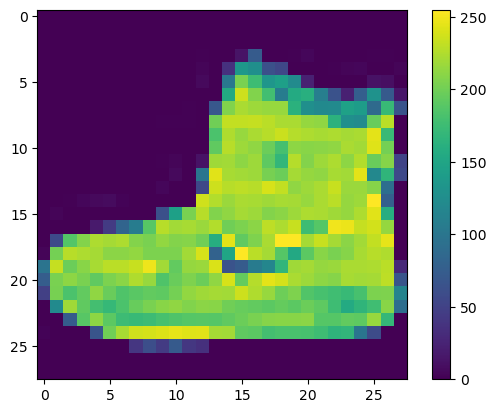

In [11]:
# plot one of the images 
plt.figure()
plt.imshow(x_train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

 pixel values of images fall in the range of 0 to 255. 
 
x_train_images will therefore need to be rescaled to values of 0 and 1 before they are put into a model. To do this, values are divided by 255. Both testing and training datasets will be processed in this way.

### Step 2: Measure of success
The accuracy metric is appropriate for this dataset as it is suitable for multi-class classification. There are a similar number of examples in each of the 10 classes - (as can been seen in the graph in step 4). 

Accuracy is the overall percentage of images that are correctly classified across all 10 classes.

### Step 3: Evaluation protocol

K-fold cross validation is the evaluation protocol of choice for this dataset as the dataset is small in terms of using Convolutional Neural Networks.  K-fold splits the dataset into K folds. Each fold is used as a validation set, the remaining folds are used as training sets. 

The following example explains how to implement K-fold validation. 
https://www.geeksforgeeks.org/deep-learning/how-to-use-k-fold-cross-validation-in-a-neural-network/


### Step 4: Data Preparation

In [12]:
# Normalize pixel values to between 0 and 1
x_train_images = x_train_images / 255
x_test_images = x_test_images / 255

Normalizing data can improve training efficiency and performance

In [13]:
"""
    Function to show a selection of the dataset

    Check to see that the images are in the correct format
    (0 or 1)
"""
def mnist_select(rows, cols):
    fig, axs = plt.subplots(rows, cols)
    for i in range(rows):
        for j in range(cols):
            axs[i, j].imshow(x_train_images[i * cols + j], cmap=plt.cm.binary)

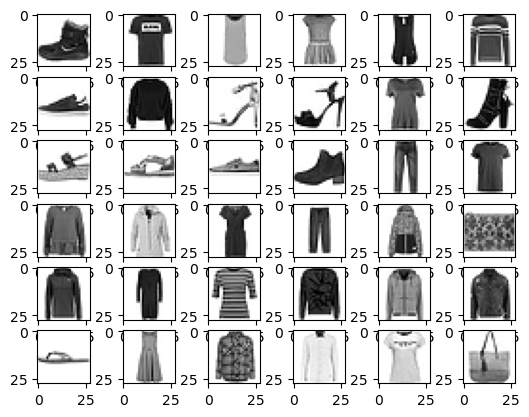

In [14]:
# print a few samples using the function created above
mnist_select(6,6)

In [20]:
# Check if a prediction has the correct label.
print(y_test_labels[1]) 

2


The prediction is class 2 = pullover

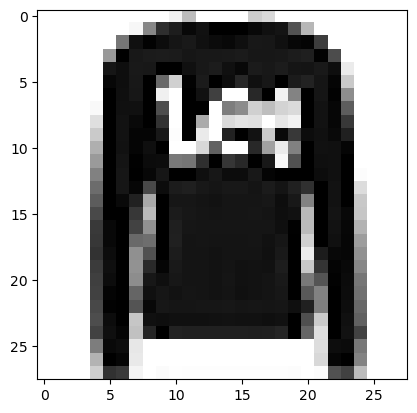

In [21]:
# Display the predicted image
plt.imshow(x_test_images[1], cmap=plt.cm.binary)
plt.show()

The predicted class and the image displayed is correct = pullover

C:\Users\becky\AppData\Local\Temp\ipykernel_23168\2310883807.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_labels, palette='viridis')


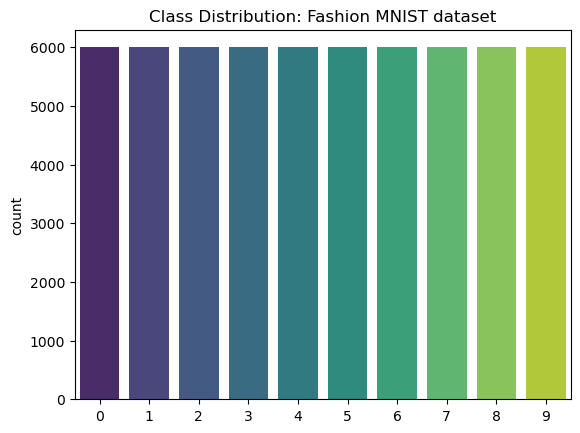

In [22]:
# Display the class distribution of the fashion MNIST dataset
sns.countplot(x=y_train_labels, palette='viridis')
plt.title("Class Distribution: Fashion MNIST dataset")
plt.show()

The dataset is well balanced across the 10 classes in the training set. The models have the potential to learn effectively without bias and are more likely to generalize well. 

In [23]:
# Add an empty channel for CNN: (28, 28) -> (28, 28, 1)
x_train_images = x_train_images.reshape(-1, 28, 28, 1)
x_test_images = x_test_images.reshape(-1, 28, 28, 1)

Modify the convolution layer to accept single-channel inputs by setting the kernel depth to 1.

### Baseline Model
Two convolutional layers are used in the baseline model with a dimension of 3 x 3 and Max Pooling with a dimension of 2 x 2. A flatten layer before A fully connected dense layer of 64 neurons with softmax to classify the output into 10 classes. ReLU activation functions. 

In [24]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Baseline model

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Flatten
        - Dense(64, ReLU)
        - Dense(num_classes, Softmax)
        
 """
# Build the CNN model
base_model = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

C:\Users\becky\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Flatten provides features to the classifier. The main reason for the flatten operation is to reshape the input data into a one-dimensional vector to be fed to the fully connected dense layers. In this case, the two-dimensional vector is converted to a one-dimensional one. 
https://medium.com/@prudhviraju.srivatsavaya/flatten-layer-implementation-advantage-and-disadvantages-0f8c4ecf5ac5

Between the feature extractor and the output layer, a dense layer is added to interpret the features, in this case 64 neurons.

All layers use a ReLU activation function. ReLU is computational efficienct and has the ability to alleviate the vanishing gradient problem.
https://www.geeksforgeeks.org/deep-learning/choosing-the-right-activation-function-for-your-neural-network/

The Softmax activation function is used in order to predict the probability distribution of multiclass classification - in this case there are 10 classes.

In [25]:
# Compile the base model
base_model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

The categorical cross-entropy loss function is suitable for multi-class classification. Sparse categorical cross-entropy is a version of categorical cross-entopy which avoids converting labels to one-hot format, making it more memory-efficient and faster for large datasets or many classes. Accuracy is the reporting metric used.
https://www.numberanalytics.com/blog/sparse-categorical-cross-entropy-deep-dive

https://github.com/CrimeWizard/optimization-methods-comparison
Stochastic gradient descent came out on top in the optimization methods comparison, with rmsprop and adam optimizers fairing worse.

Experiments using the adam and rmsprop optimizers were done on model 1, results indicate very high overfitting when compared to using the sgd optimizer.

In [26]:
# Print base model summary
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the base model
history = base_model.fit(x_train_images, y_train_labels, epochs=20, 
                    validation_data=(x_test_images, y_test_labels));

In [28]:
# Evaluate the model
test_loss, test_acc = base_model.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8927 - loss: 0.2961
Test accuracy: 0.8927


#### Results of the base model 
Results over the 20 epochs indicate that:
training accuracy increases from 67% to almost 91%.  
Training loss decreases from 0.9098to 0.2468.
Validation accuracy increases from 77% to 89% overall.
Validation loss decreases from 0.6215to 0.2468.
A final validation accuracy of 89% and a loss of 0.2961 is achieved.

The model is relatively good although it is overfitting somewhat. Training accuracy is higher than validation accuracy so it performs well on the training data but not as well on unseen data.

In [29]:
# Get Model Predictions for test data
predictions = base_model.predict(x_test_images)  # This returns probabilities
predicted_classes = np.argmax(predictions, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.80      0.84      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.84      0.81      0.83      1000
       Dress       0.93      0.87      0.90      1000
        Coat       0.79      0.88      0.83      1000
      Sandal       0.98      0.97      0.97      1000
       Shirt       0.68      0.73      0.71      1000
     Sneaker       0.94      0.95      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



The model predicts trousers, sandlals, sneakers,bags, dresses, and ankle boots well.
The model struggles with shirts in particular.
The model is less accurate in predicting t-shirts/tops, coats, and pullovers.

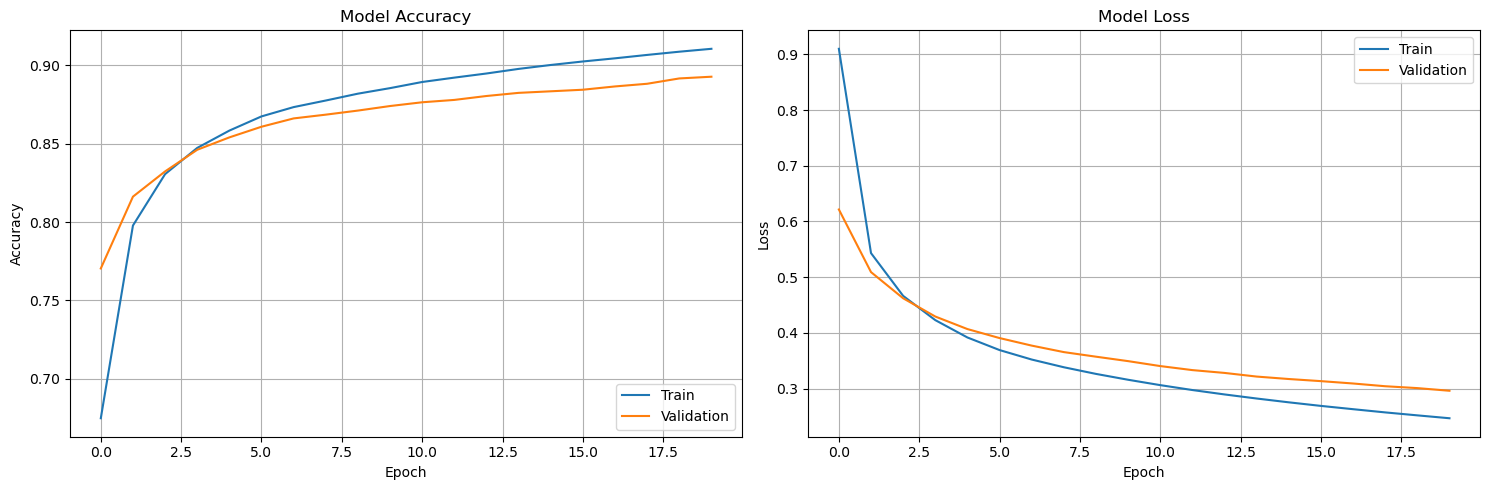

In [30]:
""" Fuction to plot training and validation accuracy and loss
    
    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 4
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history(history)

#### Evaluation Protocol
K-Fold Cross Validation
Inspired by: https://www.geeksforgeeks.org/deep-learning/how-to-use-k-fold-cross-validation-in-a-neural-network/

In [31]:
# K-Fold Cross Validation
# Set up K-Fold Cross-Validation
from sklearn.model_selection import KFold
k = 5  # Number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=13)

In [32]:
# List to store accuracy for each fold
accuracy_per_fold = []

In [33]:
# Define input_shape before using it
input_shape = (28, 28, 1)

In [34]:
# K-Fold Cross-Validation
accuracy_per_fold = []  # Initialize this list to store accuracy values

for fold, (train_index, val_index) in enumerate(kf.split(x_train_images)):
    print(f'Fold {fold + 1}')
    
    # Split the data into training and validation sets for this fold
    x_train_fold, x_val_fold = x_train_images[train_index], x_train_images[val_index]
    y_train_fold, y_val_fold = y_train_labels[train_index], y_train_labels[val_index]

    # Create a new instance of the model for each fold
    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs =inputs)  # This returns a tensor, not a model
    
    # Create a proper model using the functional API
    model_eval = tf.keras.Model(inputs=inputs, outputs=x)
    
    # Compile the model (you may need to adjust optimizer and loss function)
    model_eval.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
     
    # Train the model on the training fold
    model_eval.fit(x_train_fold, y_train_fold, epochs=5, batch_size=32, verbose=0)
    
    # Evaluate the model on the validation fold
    val_predictions = np.argmax(model_eval.predict(x_val_fold), axis=1)
    accuracy_eval = accuracy_score(y_val_fold, val_predictions)
    
    # Store the accuracy for this fold
    accuracy_per_fold.append(accuracy_eval)
    print(f'Accuracy for fold {fold + 1}: {accuracy_eval * 100:.2f}%')

# Calculate the average accuracy across all folds
average_accuracy = np.mean(accuracy_per_fold)
print(f'\nAverage Accuracy Across {k} Folds: {average_accuracy * 100:.2f}%')

Fold 1
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy for fold 1: 89.69%
Fold 2
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy for fold 2: 92.24%
Fold 3
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy for fold 3: 93.62%
Fold 4
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy for fold 4: 95.04%
Fold 5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy for fold 5: 96.38%

Average Accuracy Across 5 Folds: 93.39%


The reason for using k-fold cross validation is to avoid overfitting a model. In addition, it provides a more robust evaluation of a model. Bias and variance is reduced over a number of iterations of that averages results. Avoids Overfitting: Ensures that the model does not perform well only on the training data but generalizes to unseen data.

The average accuracy of the base model across the 5 folds is 93% which is not bad, but could be improved by various methods such as increasing the number of convolutions, hyperparameter tuning, adding to dense layers and data augmentation.

### Step 5: Develop and compare 2 small models that do better than the baseline

#### Develop the models:
1. Model 1: 2 intermediate layers each layer has equal number of hidden units.
2. Model 2: 2 intermediate layer and number of hidden units = sum of hidden units in 2 intermediate layers of Model 1.

#### Compare the models:
1. Identify optimal epochs based on validation plots for both models and explain rationale.
2. Discuss overfitting for both models
3. Discuss which model is better

### Model 1: 
2 intermediate layers each layer has equal number of hidden units.

Add 2 dense layers with equal number of units - 128 each.
More neurons will assist in better complex pattern learning.

Add Dropout (0.4) to the top end of the classifier in the dense fully connected layer, to reduce overfitting.

In [47]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Fshion model 1

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Flatten
        - Dense(128, ReLU)
        - Dense (128, ReLu)
        - Dropout (0.4)
        - Dense(num_classes, Softmax)
        
 """
# Build the CNN model with 2 intermediate dense layers of equal size
# Add Dropout to reduce overfitting
model1 = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
        
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten and dense layers
    layers.Flatten(),
    
    # Two intermediate dense layers with equal number of units (128 each)
    layers.Dense(128, activation='relu'),  # First intermediate layer
    layers.Dense(128, activation='relu'),  # Second intermediate layer
    layers.Dropout(0.4),
    
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

C:\Users\becky\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [80]:
# Print fashion model 1 summary
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
# Compile fashion model 1
model1.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train fashion model 1
history1 = model1.fit(x_train_images, y_train_labels, epochs=20, 
                    validation_data=(x_test_images, y_test_labels))

In [51]:
# Evaluate fashion model 1 using sgd optimizer
test_loss1, test_acc1 = model1.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc1:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8909 - loss: 0.3005
Test accuracy: 0.8909


In [53]:
# Predictions for fashion model 1
predictions1 = model1.predict(x_test_images)  # This returns probabilities
predicted_classes1 = np.argmax(predictions1, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes1, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.81      0.84      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.85      0.79      0.82      1000
       Dress       0.92      0.87      0.90      1000
        Coat       0.77      0.88      0.82      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.68      0.71      0.69      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.97      0.98      0.97      1000
  Ankle boot       0.95      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



The model predicts trouser, sandals, sneakers and ankle boots well.
The model struggles with shirts and coats. It achieves relatively high accuracy with t-shirts / tops and dresses.

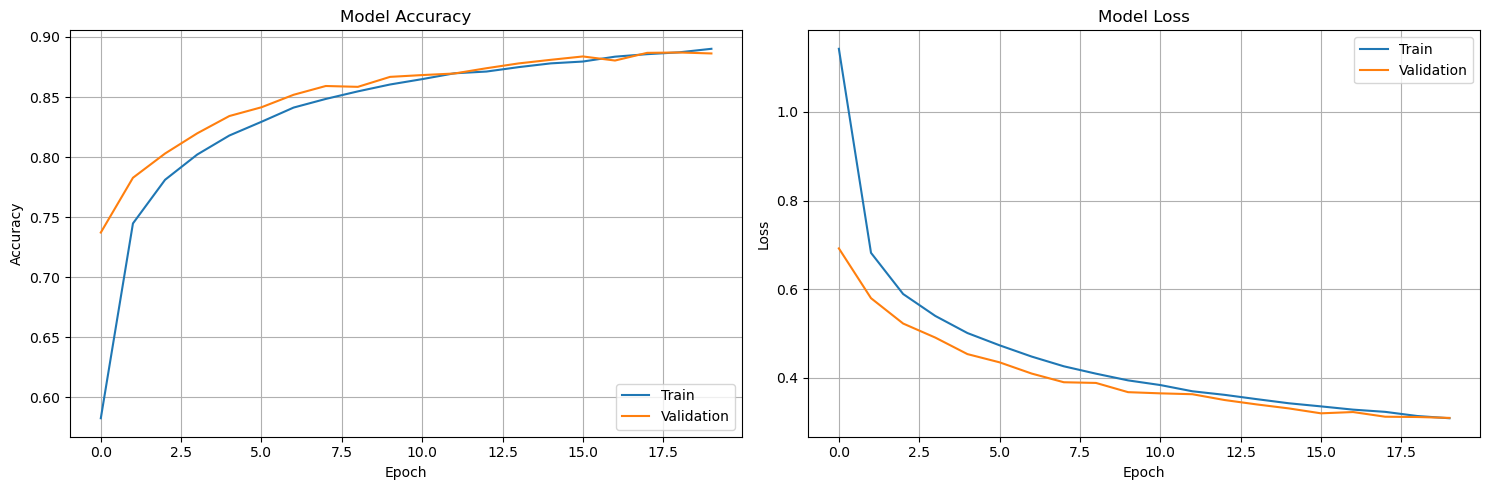

In [42]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 1
def plot_history1(history1):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history1.history['accuracy'])
    ax1.plot(history1.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history1.history['loss'])
    ax2.plot(history1.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history1(history1)

The model fits better than the base model due to Dropout and intermediate dense layers, especially after epoch 10, a Test accuracy of 89% is achieved after 20 epochs. Although model 1 has a similar validation accuracy to the base model, it is not overfitting as much. Training and validation accuracy remains quite similar after epoch 10. Validation loss is reduced from 0.6637 to 0.3005.

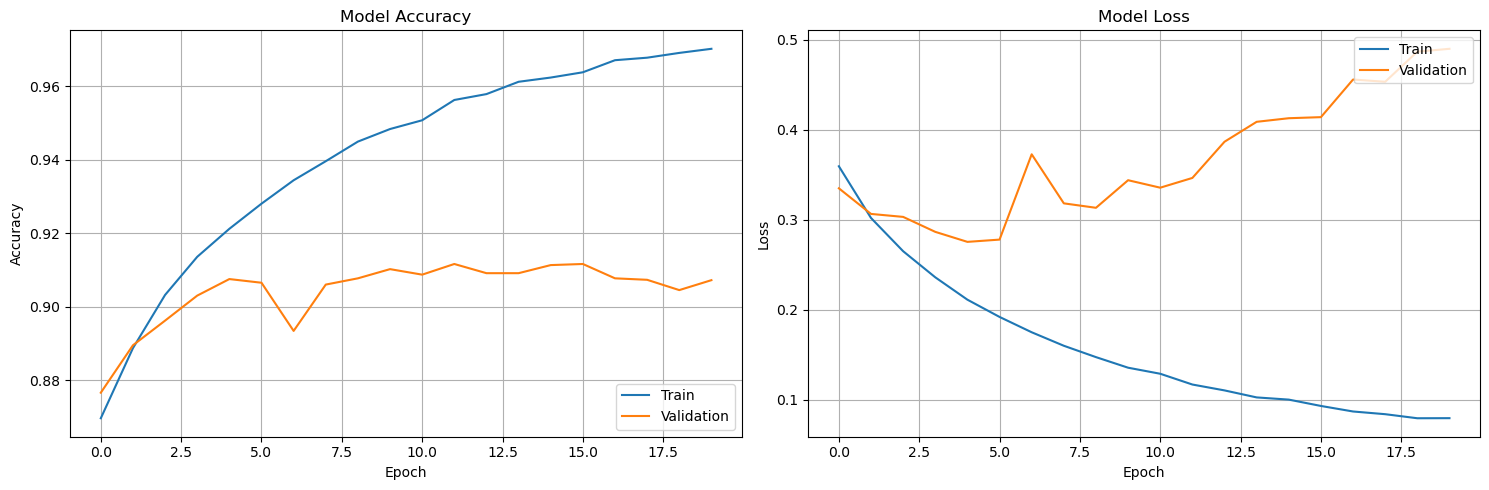

In [77]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 1
# adam optimizer is used rather than sgd
def plot_history1b(history1b):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history1b.history['accuracy'])
    ax1.plot(history1b.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history1b.history['loss'])
    ax2.plot(history1b.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history1b(history1b)

Model 1 is repeated with the adam optimizer rather than the sgd optimizer.
This optimizer leads to major overfitting.

### Model 2: 
2 intermediate layer and number of hidden units = sum of hidden units in 2 intermediate layers of Model 1 = 128 units

In [54]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Fshion model 2

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Flatten
        - Dense(256, ReLU)
        - Dense (256, ReLu)
        - Dropout (0.4)
        - Dense(num_classes, Softmax)
        
 """
# Build the CNN model with 2 intermediate dense layers of equal size
model2 = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
  
    # Flatten and dense layers
    layers.Flatten(),
        
    # Two intermediate dense layers with  (256 each)
    layers.Dense(256, activation='relu'),  # One intermediate layer of 256 units
    layers.Dense(256, activation='relu'), # Another intermediate layer of 256 units
    layers.Dropout(0.4), # dropout to prevent overfitting
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

C:\Users\becky\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
# Print fashion model 2 summary
model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         409,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 497,034 (1.90 MB)

 Trainable params: 497,034 (1.90 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Compile fashion model 2
model2.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train fashion model 2
history2 = model2.fit(x_train_images, y_train_labels, epochs=20, 
                    validation_data=(x_test_images, y_test_labels))

Model 2 reduces the validation loss from 0.8935 to 0.2882.
It increases validation accuracy from 0.7652 to 0.8935 achieving an accuracy of 89%


In [58]:
# Evaluate fashion model 2
test_loss2, test_acc2 = model2.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc2:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8935 - loss: 0.2882
Test accuracy: 0.8935


In [59]:
# Get Model Predictions for test data
predictions2 = model2.predict(x_test_images)  # Returns probabilities
predicted_classes2 = np.argmax(predictions2, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes2, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.82      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.85      0.80      0.82      1000
       Dress       0.92      0.89      0.90      1000
        Coat       0.77      0.89      0.83      1000
      Sandal       0.96      0.98      0.97      1000
       Shirt       0.71      0.70      0.71      1000
     Sneaker       0.96      0.93      0.94      1000
         Bag       0.97      0.98      0.97      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



Model 2 struggles with shirts and coats in particular, as well as pullovers.
Model 2 predicts trousers, bags, sandals, sneakers, dresses and ankle boots well.

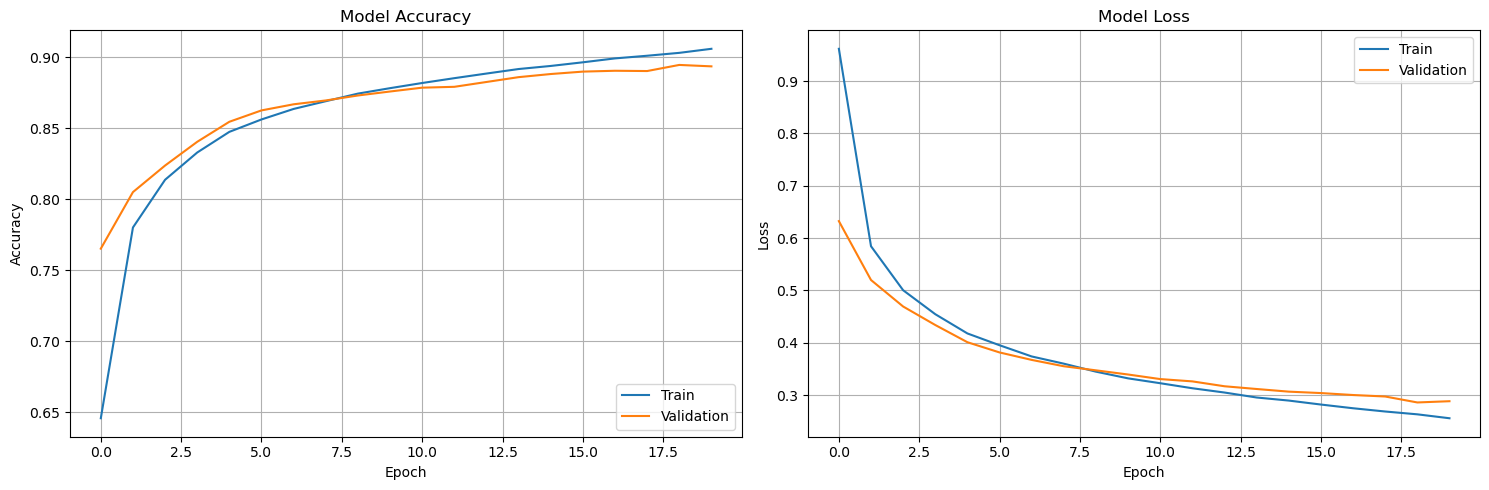

In [60]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 2
def plot_history2(history2):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history2.history['accuracy'])
    ax1.plot(history2.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history2.history['loss'])
    ax2.plot(history2.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history2(history2)

Model 2 graphs show a good fit with the training vs testing data especially after epoch 7.5

Text(0.5, 1.0, 'Training - Accuracy: Model 1 and Model 2')

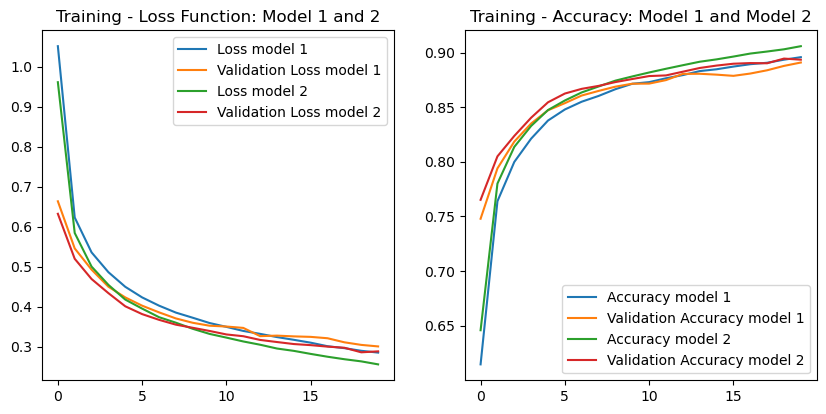

In [83]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.plot(history1.history['loss'], label='Loss model 1')
plt.plot(history1.history['val_loss'], label='Validation Loss model 1')
plt.plot(history2.history['loss'], label='Loss model 2')
plt.plot(history2.history['val_loss'], label='Validation Loss model 2')
plt.legend()
plt.title('Training - Loss Function: Model 1 and 2')

plt.subplot(2, 2, 2)
plt.plot(history1.history['accuracy'], label='Accuracy model 1')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy model 1')
plt.plot(history2.history['accuracy'], label='Accuracy model 2')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy model 2')

plt.legend()
plt.title('Training - Accuracy: Model 1 and Model 2')

In [84]:
# Compare results
print(f"Final Test Accuracy - Base Model: {test_acc:.4f}")
print(f"Final Test Loss - Base Model: {test_loss:.4f}")
print(f"Final Test Accuracy - Model 1: {test_acc1:.4f}")
print(f"Final Test Loss - Model 1: {test_loss2:.4f}")
print(f"Final Test Accuracy - Model 2: {test_acc2:.4f}")
print(f"Final Test Loss - Model 2: {test_loss2:.4f}")

Final Test Accuracy - Base Model: 0.8927
Final Test Loss - Base Model: 0.2961
Final Test Accuracy - Model 1: 0.8909
Final Test Loss - Model 1: 0.2882
Final Test Accuracy - Model 2: 0.8935
Final Test Loss - Model 2: 0.2882


The base model has a higher training accuracy than model 1 but is lower than model 2. The disparity between the training accuracy and the test accuracy in the base model indicate overfitting.

Model 2 gives the best overall performance with the highest accuaracy (89.35%) and the test loss equals model 1 at 0.2882.  

Model 1 and 2 have added layers and more neurons than the base model.  In addition, Dropout has been added to the top end of the classifier in both models which assists in reducing overfitting.

https://medium.com/@zeynepsoyan/ml-classification-with-fashion-mnist-a-comparison-of-algorithms-58008e1b29a5

### Step 6: Scaling up - develop a model that overfits

In [85]:
# Create a small subset of the data to make overfitting more obvious
train_size = 1000
x_train_small = x_train_images[:train_size]
y_train_small = y_train_labels[:train_size]

In [86]:
# Build an overly complex model for the task
model3 = Sequential([
    # Convolutional layers with many filters
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    # Very large dense layers
    Dense(1024, activation='relu'),
    Dense(1024, activation='relu'),
    Dense(512, activation='relu'),
    # No dropout or regularization to allow overfitting
    Dense(10, activation='softmax')
])

C:\Users\becky\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [87]:
# Compile fashion model 3
model3.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [88]:
# Print fashion model 3 summary
model3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 28, 28, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 14, 14, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 14, 14, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 7, 7, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 7, 7, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 3, 3, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1024)                │       2,360,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1024)                │       1,049,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,084,106 (19.39 MB)

 Trainable params: 5,084,106 (19.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model for many epochs to encourage overfitting
# Use a small subset of data
history3 = model3.fit(
    x_train_small, y_train_small,
    epochs=50,  # Many epochs
    batch_size=32,
    validation_data=(x_test_images, y_test_labels),
    verbose=1
)

In [90]:
# Evaluate fashion model 3
test_loss3, test_acc3 = model3.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc3:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7322 - loss: 0.8441
Test accuracy: 0.7322


In [91]:
# Get Model Predictions for test data for fashion model 3
predictions3 = model3.predict(x_test_images)  # Returns probabilities
predicted_classes3 = np.argmax(predictions3, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes3, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.49      0.62      1000
     Trouser       0.99      0.61      0.75      1000
    Pullover       0.68      0.57      0.62      1000
       Dress       0.75      0.73      0.74      1000
        Coat       0.60      0.78      0.68      1000
      Sandal       0.95      0.82      0.88      1000
       Shirt       0.32      0.52      0.40      1000
     Sneaker       0.84      0.92      0.88      1000
         Bag       0.86      0.95      0.91      1000
  Ankle boot       0.89      0.92      0.91      1000

    accuracy                           0.73     10000
   macro avg       0.77      0.73      0.74     10000
weighted avg       0.77      0.73      0.74     10000



Model 3 cannot predict shirts or coats and pullovers well at all.
It is still able to predict trousers and sandals well.

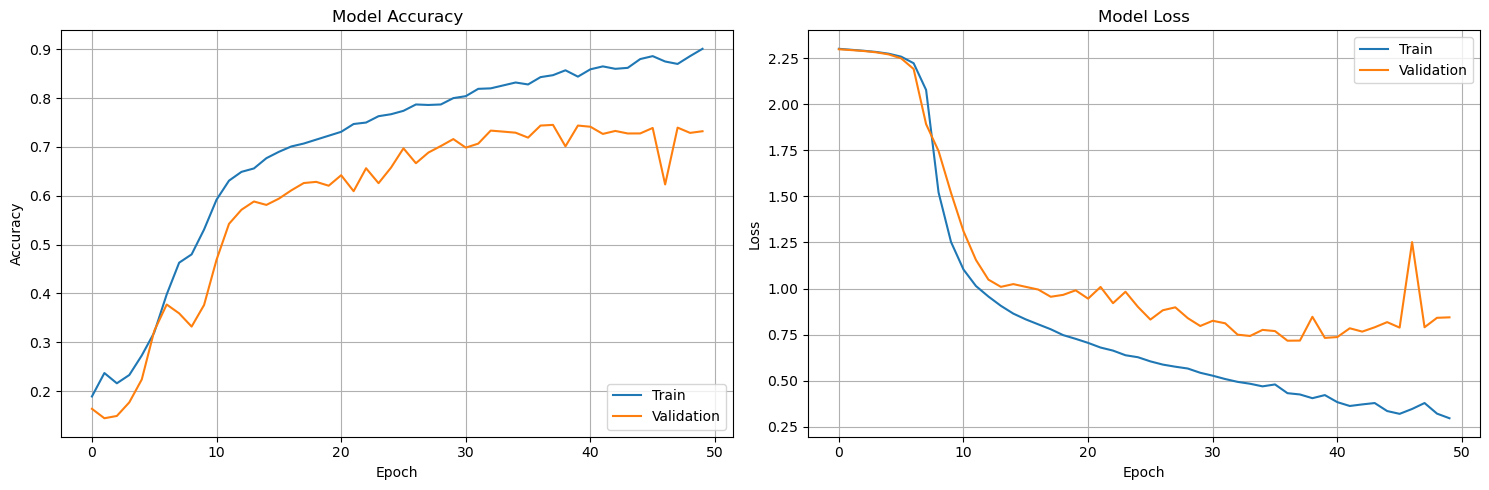

In [92]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 4
def plot_history3(history3):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history3.history['accuracy'])
    ax1.plot(history3.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history3.history['loss'])
    ax2.plot(history3.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history3(history3)

Training accuracy increases, reaching 90%; validation accuracy stalls at about 75%
Training loss decreases to 0.25; validation loss reaches its minimum after 35 epochs, then stalls
Having fewer training samples leads to overfitting as does the increase in epochs.

### Step 7: Regularising your model and tuning hyperparameters using each of the methods below.

1. Add dropout
2. Try different architectures: add or remove layers
3. Add L1 and or L2 regularization
4. Try a combination of at least 2 methods

#### Model 4:
Regularizing with dropout in Dense layer

In [93]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Fshion model 4

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Flatten
        - Dense(64, ReLU)
        - Dense (64, ReLu)
        - Dropout (0.25)
        - Dense(num_classes, Softmax)
        
 """
# Reduce the dropout to 0.25 in the top end of the classifier
# Add a third convolutional layer
model4 = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
        
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
        
    # Third convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    # Classifier head: flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(64, activation='relu'),  # One intermediate layer
    
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

C:\Users\becky\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [94]:
# Print fashion model 4 summary
model4.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)                   │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 3, 3, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 1, 1, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 64,714 (252.79 KB)

 Trainable params: 64,714 (252.79 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
# Compile fashion model 4
model4.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train fashion model 4
history4 = model4.fit(x_train_images, y_train_labels, epochs=20, 
                    validation_data=(x_test_images, y_test_labels))

In [97]:
# Evaluate fashion model 4
test_loss4, test_acc4 = model4.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc4:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8637 - loss: 0.3780
Test accuracy: 0.8637


In [98]:
# Get Model Predictions for test data for fashion model 4
predictions4 = model4.predict(x_test_images)  # returns probabilities
predicted_classes4 = np.argmax(predictions4, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes4, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.81      0.81      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.78      0.79      0.79      1000
       Dress       0.90      0.83      0.87      1000
        Coat       0.73      0.83      0.78      1000
      Sandal       0.98      0.94      0.96      1000
       Shirt       0.64      0.61      0.63      1000
     Sneaker       0.94      0.92      0.93      1000
         Bag       0.94      0.97      0.96      1000
  Ankle boot       0.92      0.97      0.94      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



Model 4 predicts trousers, sandals, sneakers, ankle boots and bags well.
It performs poorly on the other categories

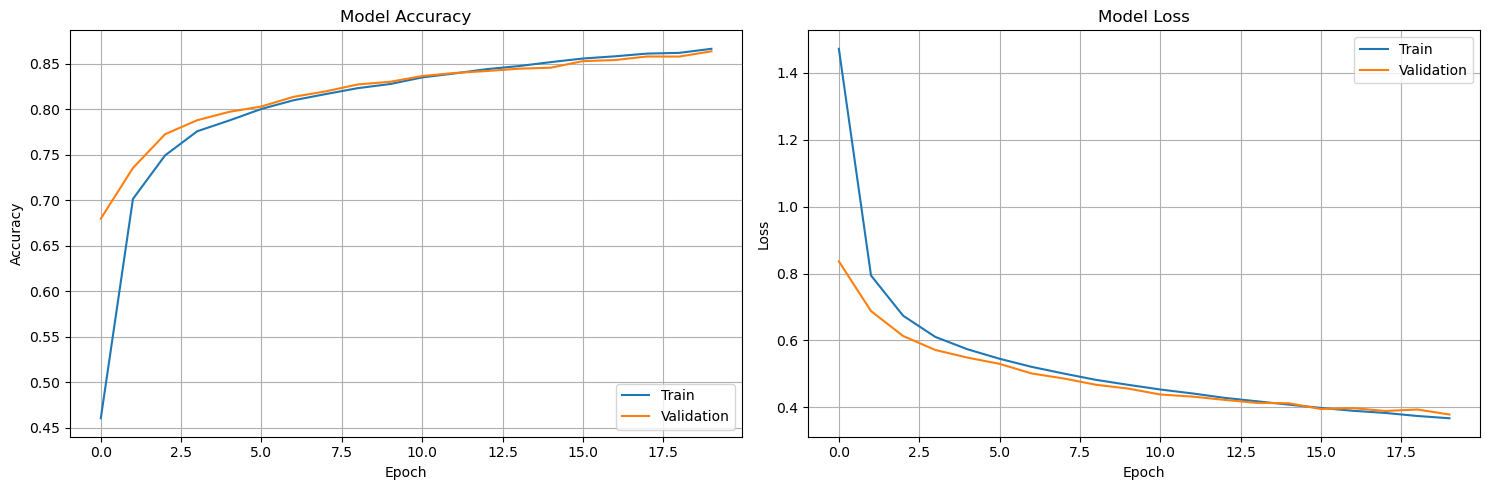

In [99]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 4
def plot_history4(history4):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history4.history['accuracy'])
    ax1.plot(history4.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history4.history['loss'])
    ax2.plot(history4.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history4(history4)

The model fits well from epoch 5.  Validation accuracy and training accuracy consistently increase to 86%.
Validation and training loss are also consistently reduced.
Increasing the number of epochs could possibly improve the model's performance.

### Model 4b: 
Increase the number of epochs

In [173]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Fshion model 4

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - MaxPooling2D(2x2)
        - Flatten
        - Dense(64, ReLU)
        - Dense (64, ReLu)
        - Dropout (0.25)
        - Dense(num_classes, Softmax)
        
 """
# Add a third convolutional layer
# increase neurons in the dense layer
model4b = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
        
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
        
    # Third convolutional layer
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    # Classifier head: flatten and dense layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(256, activation='relu'),  # One intermediate layer
    
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

C:\Users\becky\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [132]:
# Print fashion model 4b summary
model4b.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)                   │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_30 (Conv2D)                   │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_26 (MaxPooling2D)      │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ (None, 3, 3, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_27 (MaxPooling2D)      │ (None, 1, 1, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_10 (Flatten)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 64,714 (252.79 KB)

 Trainable params: 64,714 (252.79 KB)

 Non-trainable params: 0 (0.00 B)

In [133]:
# Compile the model
model4b.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train fashion model 4b
history4b = model4b.fit(x_train_images, y_train_labels, epochs=30, 
                    validation_data=(x_test_images, y_test_labels))

In [135]:
# Evaluate fashion model 4b
test_loss4b, test_acc4b = model4b.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc4b:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8794 - loss: 0.3392
Test accuracy: 0.8794


#### Model 5: Try different architectures: add or remove layer
Increase the neurons in two intermediate Dense layers
Remove two intermediate dense layers of equal size
Remove dropout from top end of the classifier. Add dropout to the convolutional layers.
Add kernel_initializer = 'he_uniform', padding = 'same'. 'same' padding is used to preserve spatial dimensions.

In [100]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Model 5

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - Kernel initializer: he_uniform
        - Padding: same
        - BatchNormalization
        - MaxPooling2D(2x2)
        - Dropout (0.25)
        - Conv2D(64 filters, 3x3, ReLU)
        - Kernel initializer: he_uniform
        - Padding: same
        - BatchNormalization
        - MaxPooling2D(2x2)
        - Dropout (0.25)
        - Conv2D(128 filters, 3x3, ReLu)
        - Kernel initializer: he_uniform
        - Padding: same
        - Dropout (0.25)
        - Flatten
        - Dense(64, ReLU)
        - Dense(128, ReLU)
        - Dropout (0.5)
        - Dense(num_classes, Softmax)
      
"""
model5 = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', 
                  kernel_initializer ='he_uniform', padding = 'same', 
                  input_shape=(28, 28, 1)), 
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu', 
                  kernel_initializer ='he_uniform', padding = 'same',),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Third convolutional layer
    layers.Conv2D(128, (3, 3), activation='relu', 
                  kernel_initializer ='he_uniform', padding = 'same',),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Fully connected Classifier head: flatten and dense layers
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_initializer ='he_uniform'),
    layers.Dense(256, activation='relu', kernel_initializer ='he_uniform'),
       
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

C:\Users\becky\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [101]:
# Print fashion model 5 summary
model5.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)                   │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 256)                 │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 456,202 (1.74 MB)

 Trainable params: 456,202 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

In [102]:
# Compile fashion model 5
model5.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train fashion model 5
history5 = model5.fit(x_train_images, y_train_labels, epochs=20, 
                    validation_data=(x_test_images, y_test_labels))

In [104]:
# Evaluate fashion model 5
test_loss5, test_acc5 = model5.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc5:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8941 - loss: 0.2843
Test accuracy: 0.8941


In [105]:
# Get Model Predictions for test data for fashion model 5
predictions5 = model5.predict(x_test_images)  # returns probabilities
predicted_classes5 = np.argmax(predictions5, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes5, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.81      0.83      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.86      0.79      0.82      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.77      0.88      0.82      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.69      0.71      0.70      1000
     Sneaker       0.95      0.96      0.96      1000
         Bag       0.99      0.97      0.98      1000
  Ankle boot       0.96      0.97      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



#### Classification report model 5
The model is precise with trousers, and does well predicting bags, ankle boots, sandals and sneakers.
It struggles a bit with shirts, t-shirts/tops, pullovers, dresses and coats.

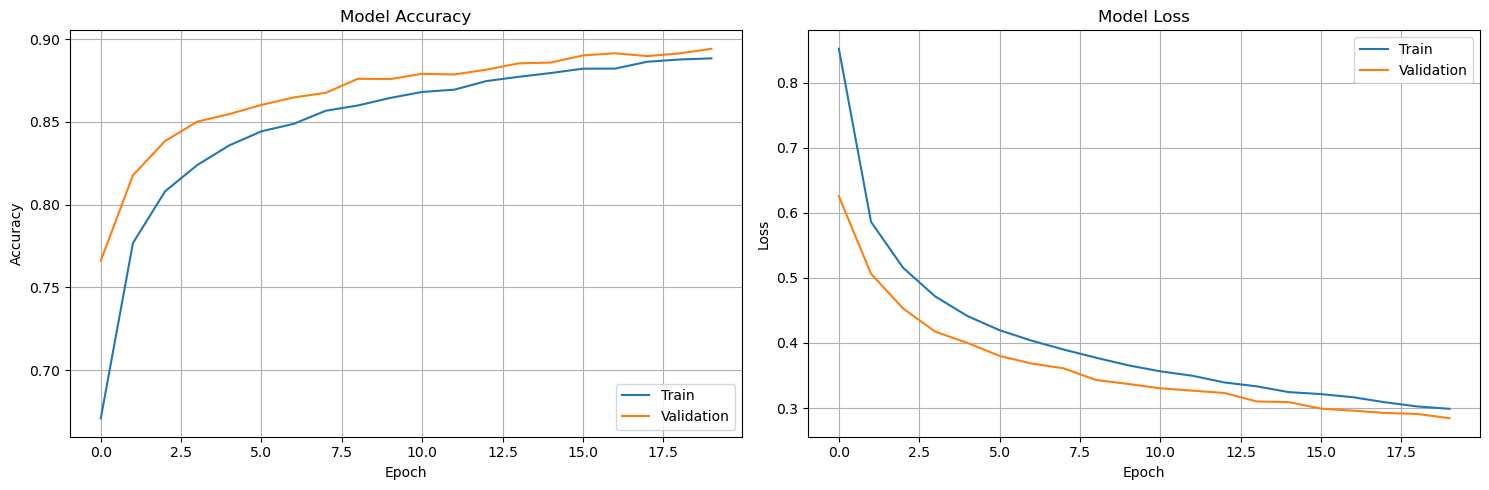

In [106]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 5
def plot_history5(history5):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history5.history['accuracy'])
    ax1.plot(history5.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history5.history['loss'])
    ax2.plot(history5.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history5(history5)

Model 5 consistently underfits. 
Dropout in the convolutional layers is most likely the problem.
Increasing the epochs could increase the goodness of fit or changing the optimizer. 
Repeat the model using the adam optimizer as a test.

Repeat the experiment with adam optimizer

In [240]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Fshion model 5b

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU), kernel_initializer = 'he_uniform', padding = 'same'
        - MaxPooling2D(2x2)
        - Dropout(0.25)
        - Conv2D(64 filters, 3x3, ReLU), kernel_initializer = 'he_uniform', padding = 'same'
        - MaxPooling2D(2x2)
        - Dropout (0.25)
        - Conv2D(64 filters, 3x3, ReLU), kernel_initializer = 'he_uniform', padding = 'same'
        - MaxPooling2D(2x2)
        - Dropout (0.25)
        - Flatten
        - Dense(256, ReLU)
        - Dense (256, ReLu)
        - Dropout (0.25)
        - BatchNormalization()
        - Dense(num_classes, Softmax)
        
 """
model5b = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same', input_shape=(28, 28, 1)), 
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
        
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'), 
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
        
    # Third convolutional layer
    layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'), 
    layers.Dropout(0.25),
    
    # Fully connected Classifier head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
       
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

C:\Users\becky\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [241]:
# Print fashion model 5b summary
model5b.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_82 (Conv2D)                   │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_64 (MaxPooling2D)      │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_59 (Dropout)                 │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_83 (Conv2D)                   │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_65 (MaxPooling2D)      │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_60 (Dropout)                 │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_84 (Conv2D)                   │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_61 (Dropout)                 │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_25 (Flatten)                 │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_67 (Dense)                     │ (None, 256)                 │       1,605,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_68 (Dense)                     │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_62 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_33               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_69 (Dense)                     │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,767,946 (6.74 MB)

 Trainable params: 1,767,434 (6.74 MB)

 Non-trainable params: 512 (2.00 KB)

In [242]:
# Compile the model
model5b.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train fashion model 5b
history5b = model5b.fit(x_train_images, y_train_labels, epochs=20, 
                    validation_data=(x_test_images, y_test_labels))

In [247]:
# Evaluate fashion model 5b
test_loss5b, test_acc5b = model5b.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc5b:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9269 - loss: 0.2128
Test accuracy: 0.9269


In [248]:
# Get Model Predictions for test data for fashion model 5b
from sklearn.metrics import classification_report
predictions5b = model5b.predict(x_test_images)  # This returns probabilities
predicted_classes5b = np.argmax(predictions5b, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes5b, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.85      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.89      0.89      0.89      1000
       Dress       0.92      0.95      0.93      1000
        Coat       0.88      0.88      0.88      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.78      0.80      0.79      1000
     Sneaker       0.97      0.97      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



Model 5b predicts trousers perfectly and does very well predicting sandals, bags, ankle boots and sneakers.
The model performs less optimally when predicting shirts particularly, but struggles with pullovers, dresses and t-shirts / tops

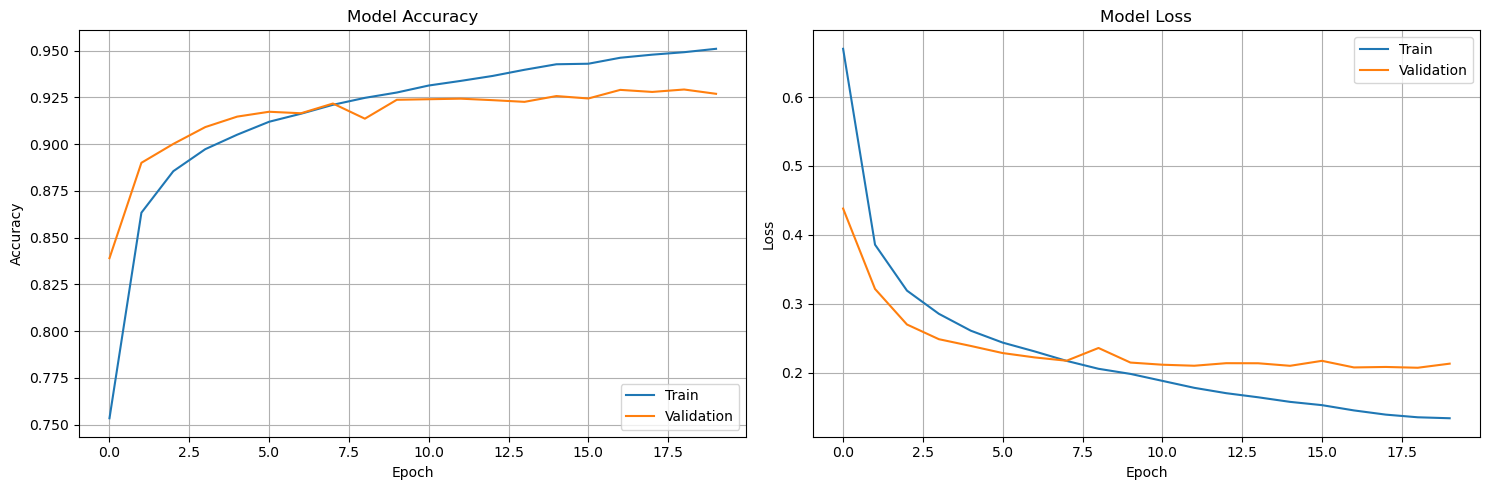

In [249]:
# Plot training & validation accuracy and loss
def plot_history5b(history5b):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history5b.history['accuracy'])
    ax1.plot(history5b.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history5b.history['loss'])
    ax2.plot(history5b.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history5b(history5b)

Model 5b is the same as Model 5 except that the adam optimizer was used to train Model 5b and the sgd optimizer was used in Model 5.
Results show that the adam optimizer performs better in a deeper more complex neural network and sgd is better in smaller less complex networks.
Various experiments with the location and use of BatchNormalization and Dropout revealed that BatchNormalization is best after Dropout. An additional convolutional layer was added to Model 5b to see how the performance changed. Results show ...
The model starts to overfit at epoch 12. The validation loss is minimized to 0.2340 then increases slightly afterwards.Validation accuracy of 92% is achieved by model 5b.

https://github.com/Net-AI-Git/02---cnn-BatchNorm-and-Dropout

#### Model 6: Add L1 and L2 regualarization
L1 and L2 regularization helps control the complexity of a model and improves its performance on unseen data.
Using these methods could help balance complexity of a model and its ability to generalize well.

In [233]:
""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Model 6b

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - Kernel initializer: he_uniform
        - Padding: same
        - BatchNormalization
        - MaxPooling2D(2x2)
        - Conv2D(64 filters, 3x3, ReLU)
        - Kernel initializer: he_uniform
        - Padding: same
        - BatchNormalization
        - MaxPooling2D(2x2)
        - Conv2D(128 filters, 3x3, ReLu)
        - Kernel initializer: he_uniform
        - Padding: same
        - Flatten
        - Dense(256, ReLU)
        - Dropout (0.5)
        - Dense(num_classes, Softmax)
      
"""
# Add L2 regularization
# Remove Dropout and batch normalization in convolutional layers
# Keep Dropout in Dense layer to avoid overfitting
# Increase Dense layer units to 256
# Remove L1 regularization
# Define regularization rates (lambda values)
l1_reg = 0.0001
l2_reg = 0.0000

model6b = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer ='he_uniform', padding = 'same', 
                  kernel_regularizer = l1_l2(l1=l1_reg, l2 = l2_reg), input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
        
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer ='he_uniform', padding = 'same',
                 kernel_regularizer = l1_l2(l1=l1_reg, l2 = l2_reg)),
        
    # Third convolutional layer
    layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer ='he_uniform', padding = 'same',
                 kernel_regularizer = l1_l2(l1=l1_reg,l2 = l2_reg)),
    layers.MaxPooling2D((2, 2)),
        
    # Fully connected Classifier head: flatten and dense layers
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_initializer ='he_uniform',
                kernel_regularizer = l1_l2(l1=l1_reg, l2 = l2_reg)),
    layers.Dropout(0.5),  
   
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

In [234]:
# Print fashion model 6 summary
model6b.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_79 (Conv2D)                   │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_62 (MaxPooling2D)      │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_80 (Conv2D)                   │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_81 (Conv2D)                   │ (None, 14, 14, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_63 (MaxPooling2D)      │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_24 (Flatten)                 │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_65 (Dense)                     │ (None, 256)                 │       1,605,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_58 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_66 (Dense)                     │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,701,130 (6.49 MB)

 Trainable params: 1,701,130 (6.49 MB)

 Non-trainable params: 0 (0.00 B)

In [235]:
# Compile fashion model 6b
model6b.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train the model
history6b = model6b.fit(x_train_images, y_train_labels, epochs=30,
                    validation_data=(x_test_images, y_test_labels))

In [244]:
# Evaluate fashion model 6b
test_loss6b, test_acc6b = model6b.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc6b:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9182 - loss: 0.4321
Test accuracy: 0.9182


In [245]:
# Get Model Predictions for test data for fashion model 6b
from sklearn.metrics import classification_report
predictions6b = model6b.predict(x_test_images)  # This returns probabilities
predicted_classes6b = np.argmax(predictions6b, axis=1)  # Get class with highest probability
print(classification_report(y_test_labels, predicted_classes6b, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.83      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.90      0.88      0.89      1000
       Dress       0.90      0.93      0.91      1000
        Coat       0.87      0.90      0.89      1000
      Sandal       0.97      0.99      0.98      1000
       Shirt       0.75      0.77      0.76      1000
     Sneaker       0.97      0.94      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



Model 6 classifies trousers and ankle boots well, it is very good at predicting sandals, bags, sandals and sneakers.
The model struggles more with shirts in particular, and less so with T-shirts / tops, pullovers, dresses and coats.

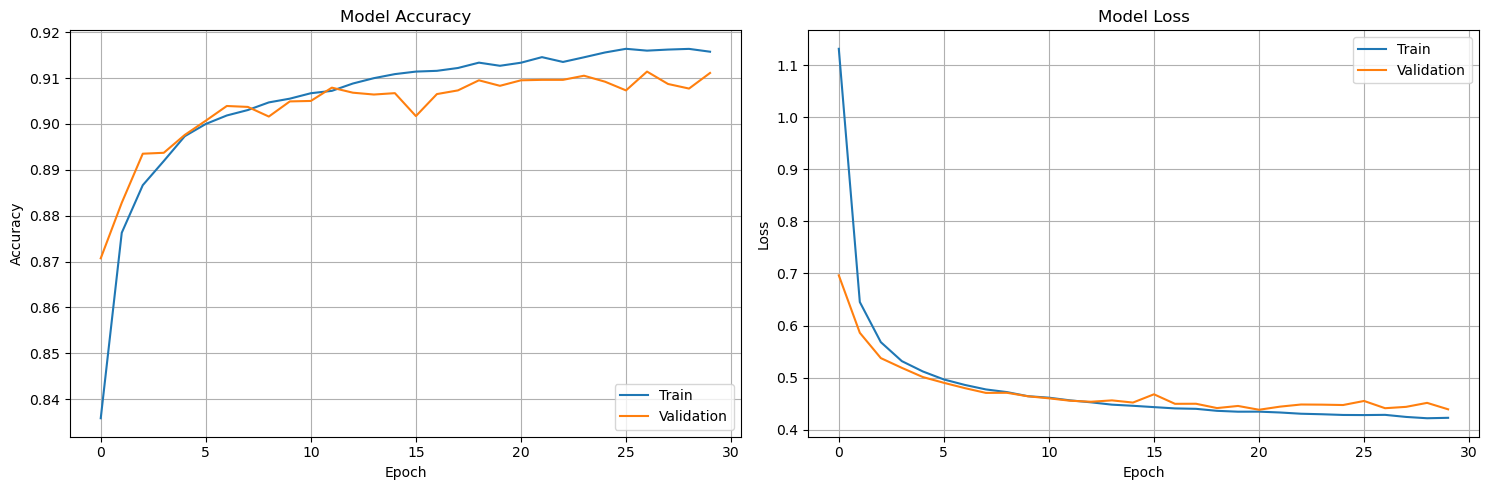

In [250]:
# Plot training & validation accuracy and loss
def plot_history6(history6):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history6.history['accuracy'])
    ax1.plot(history6.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history6.history['loss'])
    ax2.plot(history6.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history6(history6)

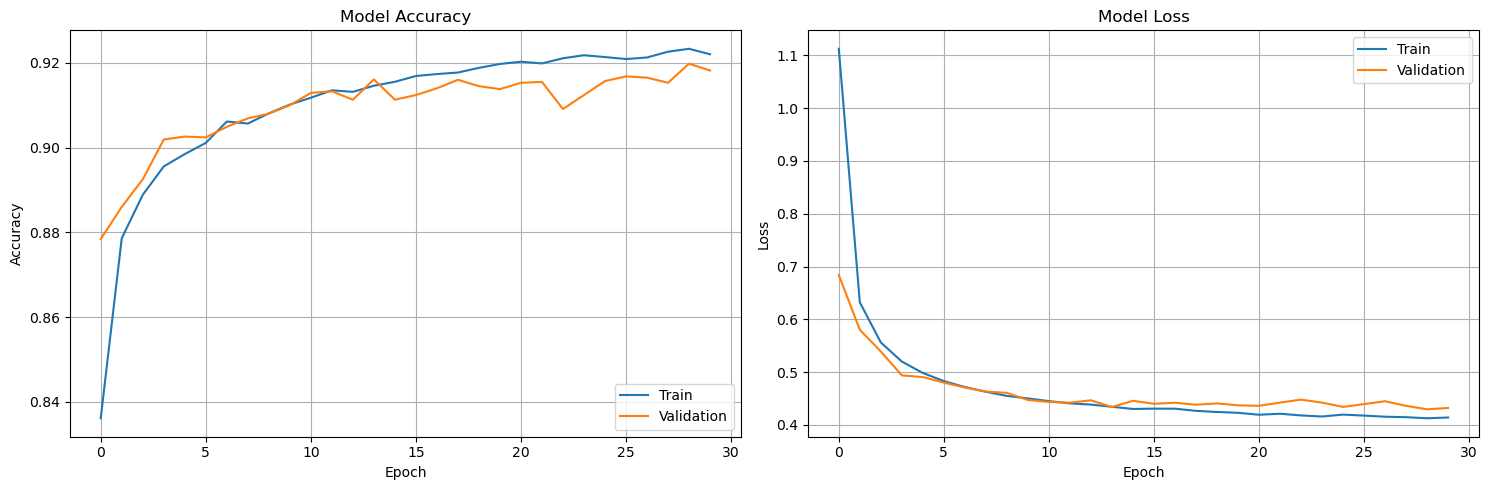

In [246]:
# Plot training & validation accuracy and loss
def plot_history6b(history6b):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history6b.history['accuracy'])
    ax1.plot(history6b.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history6b.history['loss'])
    ax2.plot(history6b.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history6b(history6b)

Due to the validation accuracy being higher than the training accuracy and validation loss higher than training loss in a few versions of Model 6, Dropout and Batch Normalization were experimented with. Various versions of the model had Batch Normalization where there was no Dropout and vice versa. Batch Normalization sped up the training process. The final model removed Batch Normalization and Dropout in the convolutional layers. Dropout was kept in the Dense layers. 
Results showed that the training and validation loss was minimized to 0.4226 and 0.4389 respectively.
Train accuracy steadily improved but validation accuracy reached its peak around 90.5% then faltered. The model started overfitting around 12 epochs.
Including data augmentation could also help improve the model. 

Model 6b was the same as Model 6, except L1 regularization was removed.
Results show that the model is overfitting from around epoch 12, the overfitting isn't too serious however.
Overall validation accuracy achieved almost 92%. 

#### Model 7
Try data augmentation to improve accuracy and precision.
Code used from: https://akanshasaxena.com/challenge/deep-learning/day-10/

In [124]:
""" Data Augmentation
    datagen.flow(X_train, y_train, batch_size=64): Generates batches of augmented data on-the-fly during training.
Validation Data: The test set is used for evaluation after each epoch.
Epochs: The model is trained for 15 epochs, giving it enough time to learn from the augmented data.

"""
# Add data augmentation
# Create an ImageDataGenerator with data augmentation settings
from tensorflow.keras.preprocessing.image import ImageDataGenerator
data_aug = ImageDataGenerator(
    rotation_range=15,          # Rotate the image by up to 15 degrees
    width_shift_range=0.1,      # Shift the width by up to 10% of the image width
    height_shift_range=0.1,     # Shift the height by up to 10% of the image height
    zoom_range=0.1,             # Zoom in by up to 10%
    horizontal_flip=True        # Randomly flip images horizontally
)

# Fit the ImageDataGenerator to the training data
data_aug.fit(x_train_images)

In [223]:
from tensorflow.keras import regularizers

""" Build a Convolutional Neural Network (CNN) model for image classification (10 classes).
    Model 7

    Parameters
    ----------
    input_shape : (height, width, channels) = (28, 28, 1) grayscale Fashion MNIST images
    num_classes : 10  = Number of output classes for classification.
     
    Returns
    -------
    A tensorflow sequential CNN Model that can be trained

    Architecture
    ------------
        - Conv2D(32 filters, 3x3, ReLU)
        - Padding: same
        - L2 regularization
        - MaxPooling2D(2x2)
        - BatchNormalization
        - Conv2D(64 filters, 3x3, ReLU)
        - L2 regularization
        - Padding: same
        - MaxPooling2D(2x2)
        - BatchNormalization
        - Conv2D(128 filters, 3x3, ReLu)
        - L2 regularization
        - Padding: same
        - BatchNormalization
        - Flatten
        - Dense(256, ReLU)
        - Dropout (0.25)
        - Dense(num_classes, Softmax)
      
"""
# Model 7 with data augmentation
model7 = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', padding = 'same', 
                  kernel_regularizer=regularizers.l2(0.0001),
                  input_shape=(28, 28, 1)), 
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
        
    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu', padding = 'same',
                  kernel_regularizer=regularizers.l2(0.0001)), 
    layers.BatchNormalization(),

     # Third convolutional layer
    layers.Conv2D(128, (3, 3), activation='relu', padding = 'same', 
                  kernel_regularizer=regularizers.l2(0.0001)),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(256, activation='relu',
                  kernel_regularizer=regularizers.l2(0.0001)),
    layers.Dropout(0.25),  # dropout to prevent overfitting
    
    # Output Layer
    layers.Dense(10, activation='softmax')  # 10 classes for Fashion MNIST
])

In [224]:
# Print fashion model 7 summary
model7.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_76 (Conv2D)                   │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_60 (MaxPooling2D)      │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_30               │ (None, 14, 14, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_77 (Conv2D)                   │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_31               │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_78 (Conv2D)                   │ (None, 14, 14, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_61 (MaxPooling2D)      │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_32               │ (None, 7, 7, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_23 (Flatten)                 │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_63 (Dense)                     │ (None, 256)                 │       1,605,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_57 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_64 (Dense)                     │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,702,026 (6.49 MB)

 Trainable params: 1,701,578 (6.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [225]:
# Compile the model
model7.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [ ]:
# Train the model using the augmented data
history7 = model7.fit(data_aug.flow(x_train_images, y_train_labels, batch_size=64),
                    validation_data=(x_test_images, y_test_labels),
                    epochs=50, verbose=1)

In [228]:
# Evaluate fashion model 7
test_loss7, test_acc7 = model7.evaluate(x_test_images, y_test_labels)
print(f'Test accuracy: {test_acc7:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9050 - loss: 0.3835
Test accuracy: 0.9050


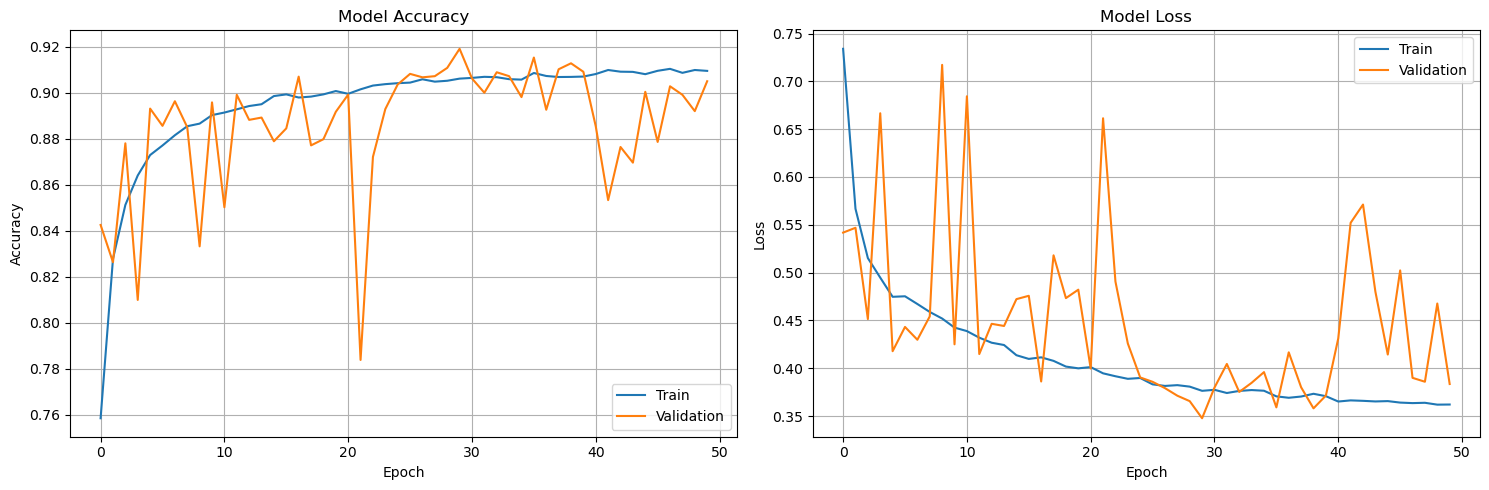

In [229]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss
def plot_history7(history7):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history7.history['accuracy'])
    ax1.plot(history7.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history7.history['loss'])
    ax2.plot(history7.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history7(history7)

### Step 8: Final model and test evaluation

1. Choose the best model on the train and the validation part of the data and evaluation it one last time on the test set.

Summary of all models:

NameVal Accuracy  Val Loss   Epochs  Description  
Base_Model  0.8927    0.2961   20 sgd
Model1 0.8863 0.3095 20 adam
Model2 0.8935 0.02882 20 sgd
Model3 0.7322 0.8441 20 sgd
Model4 0.8637 0.3780 20 sgd
Model5 0.8941 0.2843 20 adam
Model5b 0.9217 0.2340 20 adam
Model6 0.9111 0.4389 20 adam
Model6b 
Model7 0.9173 0.2320 50 adam

| Column 1 | Column 2 | Column 3 |
|:--------:|:--------:|:--------:|
| Row 1 | Row 1 | Row 1 |
| Row 2 | Row 2 | Row 2 |
| Row 3 | Row 3 | Row 3 |

|Name |Val Acc |Val loss|Optimizer|Epochs|Description| 
|-----|:-------|:------:|:-------:|:-----|:---------:|
|Base_model|0.8927 |0.2961|sgd optimizer|20|The model overfits|
|Model1|0.8863|0.3095|sgd optimizer|20|Nice convergence, but lower accuracy|
|Model2|0.8935|0.2882|adam optimizer|20|The model overfits|
|Model3|0.7322|0.8441|sgd|50|Model overfits|
|Model4|0.8637|0.3780|sgd|20|Nice fit, but lower accuracy|
|Model4b|0.8794|0.3392|sgd|30|More epochs, same as Model4| Model has lower accuracy|
|Model5|0.8941|0.2843|sgd optimizer|20|The model underfits|
|Model5b|0.9217|0.2340|adam optimizer|20|The model overfits from epoch 7|
|Model6|0.9111|0.4389|adam optimizer|20|The model overfits badly from epoch 12|
|Model6b|0.9182|0.4321|adam optimizer|30|The model does overfit from around epoch 12, but generally fits well|
|Model7|0.9173|0.2320|adam optimizer|50|erratic modelling, needs more epochs to learn possibly|

#### Model 6b
Fashion Model 6b appears to be the best fitting of all the models. Initially BatchNormalization was included with Dropout in the Convolutional layers, this was subsequently removed and the model performed better. Dropout of 0.5 was kept in the top end of the classifier in the fully conected Dense layer in order to reduce the effects of overfitting.  The he_uniform kernel initializer as well as padding = 'same' were also kept in the model.  One intermediate Dense layers with 256 units were kept.
L1 regularization was removed and L2 kept.
A test accuracy of 0.9182 was obtained.
Training and validation accuracy is consistently similar in this model.

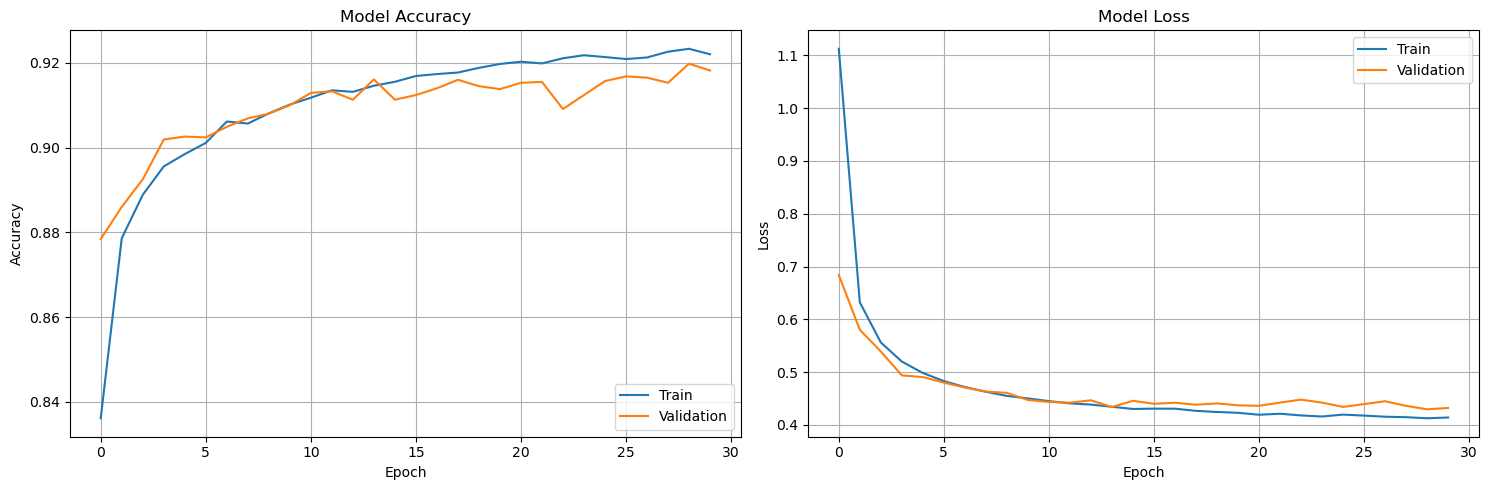

In [261]:
""" Fuction to plot training and validation accuracy and loss

    Plots training and validation accuracy graph
    Plots training and validation loss graph
    
"""  
# Plot training & validation accuracy and loss for fashion model 5
def plot_history6b(history6b):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history6b.history['accuracy'])
    ax1.plot(history6b.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Loss
    ax2.plot(history6b.history['loss'])
    ax2.plot(history6b.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history6b(history6b)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9141 - loss: 0.4393
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


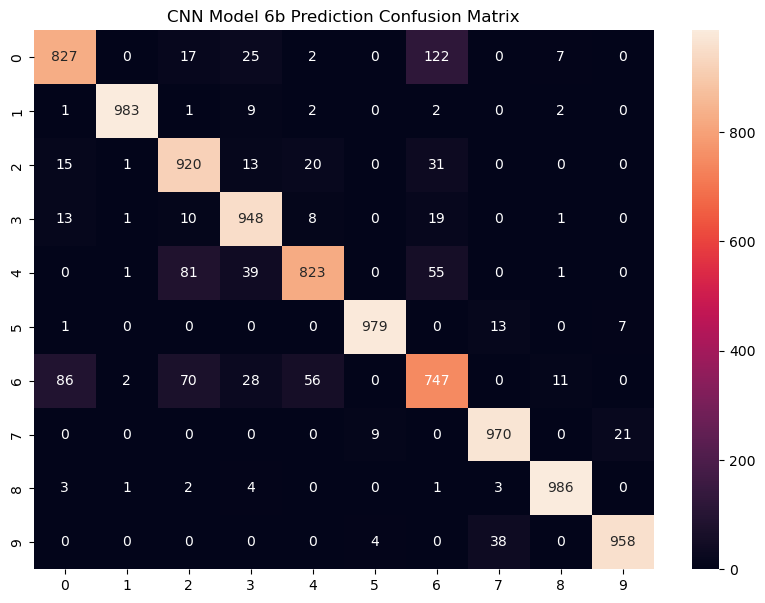

In [257]:
# Evaluate model6b
model6b.evaluate(x_test_images, y_test_labels)

y_pred = model6b.predict(x_test_images)

# Get the class with the highest predicted probability
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix model6b
cm = confusion_matrix(y_test_labels, y_pred_classes)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt = 'd')
plt.title("CNN Model 6b Prediction Confusion Matrix")
plt.show()

In [260]:
# Get Model Predictions for test data for fashion model 6b
print(classification_report(y_test_labels, predicted_classes6b, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.90      0.83      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.90      0.88      0.89      1000
       Dress       0.90      0.93      0.91      1000
        Coat       0.87      0.90      0.89      1000
      Sandal       0.97      0.99      0.98      1000
       Shirt       0.75      0.77      0.76      1000
     Sneaker       0.97      0.94      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



Overall accuracy is at 91.41%. Class 6 (shirt) has a lower F1 score , it is being classified as class 0 (tshirt / top) often and vice versa, false positives. Class 0 and class 6 (shirt) are quite similar in look. Class 4 (coat) is being misclassified as class 6 quite often too.  

In [251]:
# K-Fold Cross-Validation
k = 5  # Number of folds
kf1 = KFold(n_splits=k, shuffle=True, random_state=13)
accuracy_per_fold1 = []  # Initialize this list to store accuracy values

for fold1, (train_index, val_index) in enumerate(kf.split(x_train_images)):
    print(f'Fold {fold1 + 1}')
    
    # Split the data into training and validation sets for this fold
    x_train_fold1, x_val_fold1 = x_train_images[train_index], x_train_images[val_index]
    y_train_fold1, y_val_fold1 = y_train_labels[train_index], y_train_labels[val_index]

    # Create a new instance of the model for each fold
    inputs = tf.keras.Input(shape=input_shape)
    x = model6b(inputs =inputs)  # This returns a tensor, not a model
    
    # Create a proper model using the functional API
    model_eval1 = tf.keras.Model(inputs=inputs, outputs=x)
    
    # Compile the model (you may need to adjust optimizer and loss function)
    model_eval1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
     
    # Train the model on the training fold
    model_eval1.fit(x_train_fold1, y_train_fold1, epochs=5, batch_size=32, verbose=0)
    
    # Evaluate the model on the validation fold
    val_predictions1 = np.argmax(model_eval1.predict(x_val_fold1), axis=1)
    accuracy_eval1 = accuracy_score(y_val_fold1, val_predictions1)
    
    # Store the accuracy for this fold
    accuracy_per_fold1.append(accuracy_eval1)
    print(f'Accuracy for fold {fold1 + 1}: {accuracy_eval1 * 100:.2f}%')

# Calculate the average accuracy across all folds
average_accuracy1 = np.mean(accuracy_per_fold1)
print(f'\nAverage Accuracy Across {k} Folds: {average_accuracy1 * 100:.2f}%')

Fold 1
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy for fold 1: 92.71%
Fold 2
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy for fold 2: 92.89%
Fold 3
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy for fold 3: 93.04%
Fold 4
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy for fold 4: 92.98%
Fold 5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy for fold 5: 93.35%

Average Accuracy Across 5 Folds: 93.00%


k-fold cross validation on the best model, namely model 6b showed high accuracy across all 5 folds
fold 1 = 92.71%
fold 2 = 92.89%
fold 3 = 93.04%
fold 4 = 92.98%
fold 5 = 93.35%
Model 6b achieved a validation accuracy of 92.69% so the results from the k-fold cross validation process corroborates this result nicely.

### Conclusion
BatchNormalization and Dropout balancing requires a lot of experimentation.
Choosing the right optimizer for the type of architecture is key. Simpler, less complex models appear to perform well with stochastic gradient descent (sgd) and more complex deeper model architectures perform better using adam optimizer.
Balancing overfitting vs underfitting requires many experiments to find the optimal performance of a model and is key to deep learning. An overfir model has more use than an underfit model. 
Changing the regularization of L1 and L2 or just L2 can make a difference to a model.
If using Data augmentation more epochs are needed for the model to learn the complex features. Computation time will be increased, but generalization may improve. 
More complex deeper models are not necessarily the best performers.  Hyperparameter tuning can be computationally expensive and not always resulting in higher validation accuracy and / or validation loss. 
The modelling process is often very much trial and error. 

### Bibliography
1. Smith, J. (2020). *Introduction to Data Science*. New York: Data Press.
2. Doe, A., & Roe, B. (2021). *Machine Learning Basics*. Journal of AI, 15(3), 45–60.
3. Brown, C. (2019). *Python for Everyone*. Retrieved from https://example.com/python-book

According to recent research [1]